# 1. Load dataset

In [23]:
import pandas as pd

In [26]:
df = pd.read_excel('/content/Mall Customers.xlsx')
df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


# 2. K-Means Clustering

In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [30]:
X = df[['Annual Income (k$)',	'Spending Score (1-100)']]

In [31]:
kmeans = KMeans(n_clusters=5, random_state=42,n_init=10)
df['cluster'] = kmeans.fit_predict(X)
df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100),cluster
0,1,M,19,High School,Married,15,39,4
1,2,M,21,Graduate,Single,15,81,2
2,3,F,20,Graduate,Married,16,6,4
3,4,F,23,High School,Unknown,16,77,2
4,5,F,31,Uneducated,Married,17,40,4


# 3. Clusters visualize karo

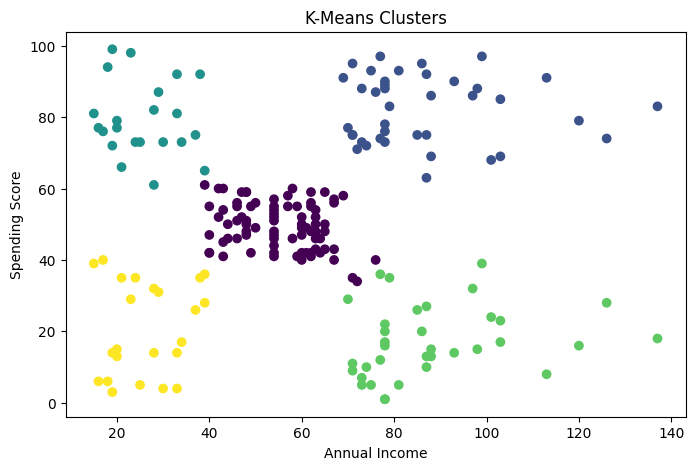

In [33]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=df["cluster"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clusters")
plt.show()

# 4. PCA se visualization

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [46]:
features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

In [47]:
X = df[features]

In [48]:
X_scaler = StandardScaler().fit_transform(X)

In [51]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaler)
print(X_pca.shape)

(200, 2)


# PCA visualization

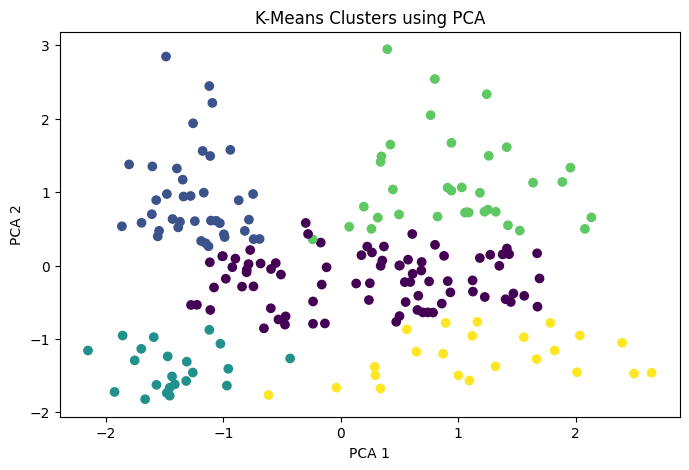

In [53]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["cluster"]
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters using PCA")
plt.show()

# 5. GridSearchCV for classifier

In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split


In [56]:
X = df[["Age", "Annual Income (k$)"]]
y = df["Spending Score (1-100)"] > 50

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [65]:
model = DecisionTreeClassifier(random_state=42)

param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 7, 8, 10, None],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 6]
}


grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [2, 3, 4, 5, 6, 7, 8, 10, None],
                         'min_samples_leaf': [1, 2, 4, 6],
                         'min_samples_split': [2, 5, 10, 15]},
             scoring='accuracy')

In [66]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'max_depth': 4, 'min_samples_leaf': 6, 'min_samples_split': 2}
Best CV Score: 0.7125


In [67]:
print("Test Accuracy:", grid.score(X_test, y_test))

Test Accuracy: 0.725


# Elbow Method

In [73]:
w = []
for i in range(1,10):
  kmeans = KMeans(n_clusters=i)
  kmeans.fit(X)
  w.append(kmeans.inertia_)

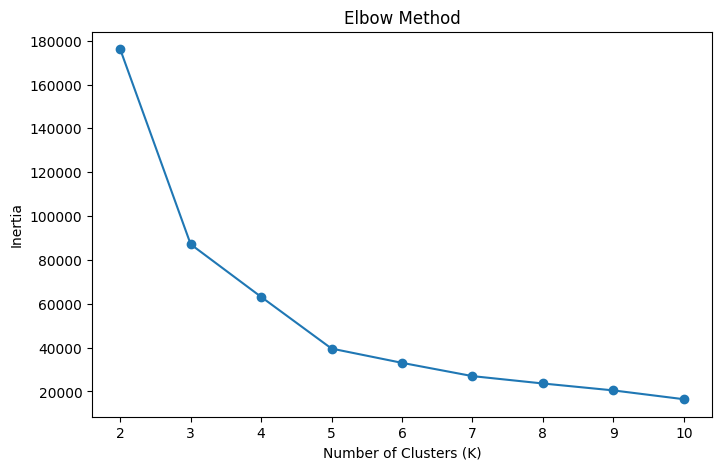

In [75]:

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), w, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Silhouette Score

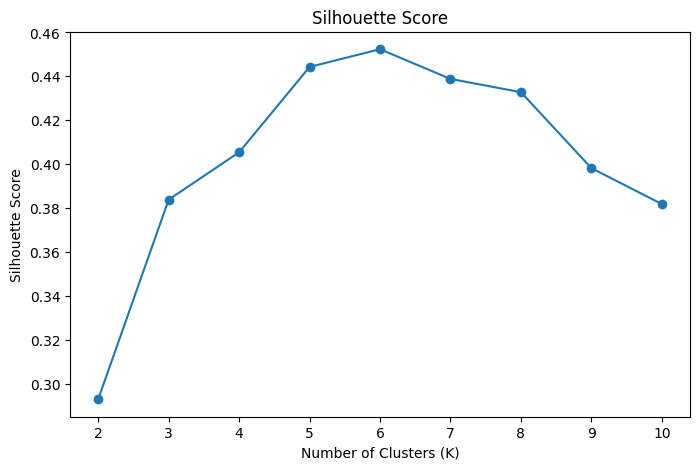

In [94]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

In [95]:
best_k = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]

print("Best K according to Silhouette Score:", best_k)
print("Best Silhouette Score:", max(silhouette_scores))

Best K according to Silhouette Score: 6
Best Silhouette Score: 0.4523443947724053
